In [1]:
import os, torch
import pandas as pd
import numpy as np
from pathlib import Path
from pathlib import PureWindowsPath
import matplotlib.pyplot as plt

# Visualize data

/tmp/ipykernel_1109276/3900946409.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))
/tmp/ipykernel_1109276/3900946409.py:10: Fu

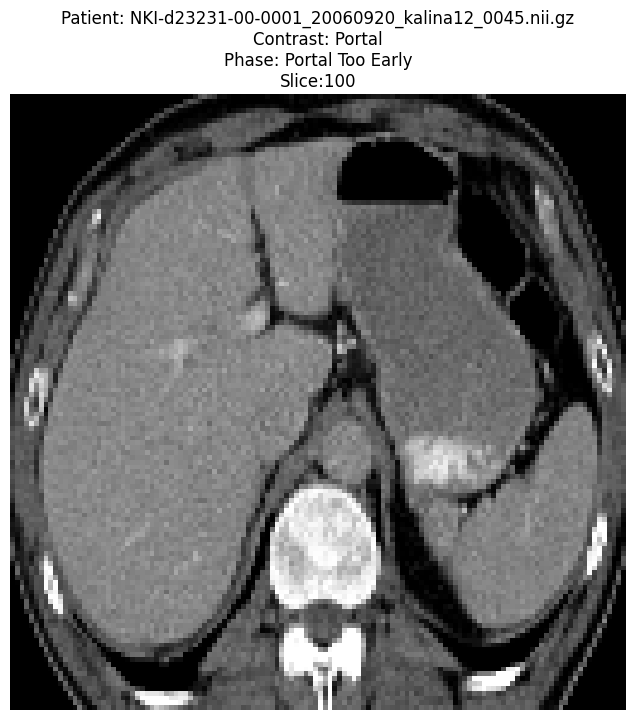

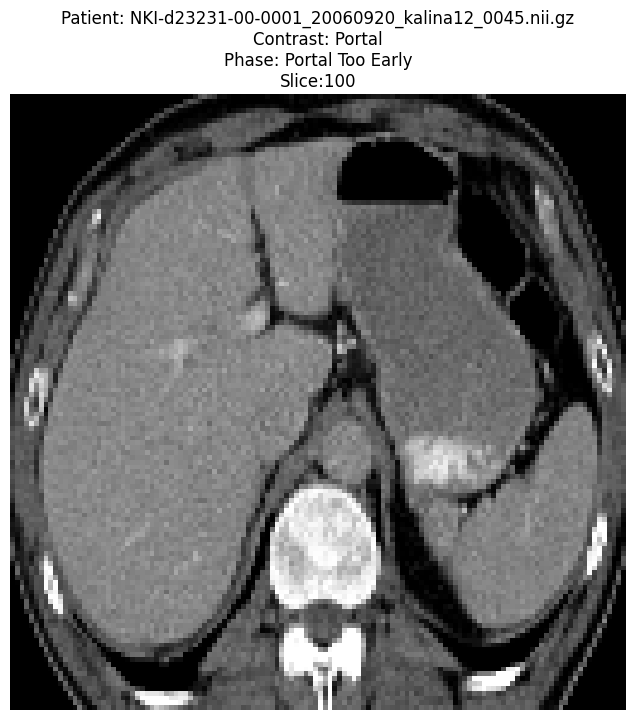

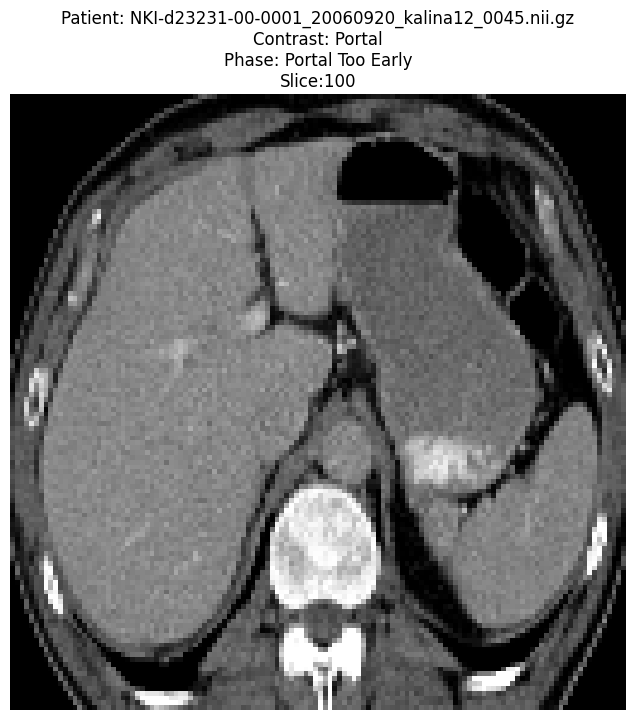

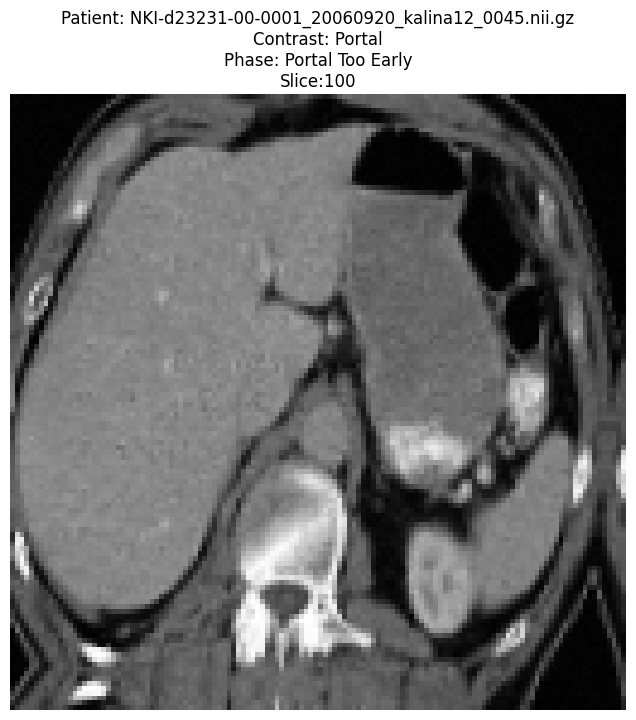

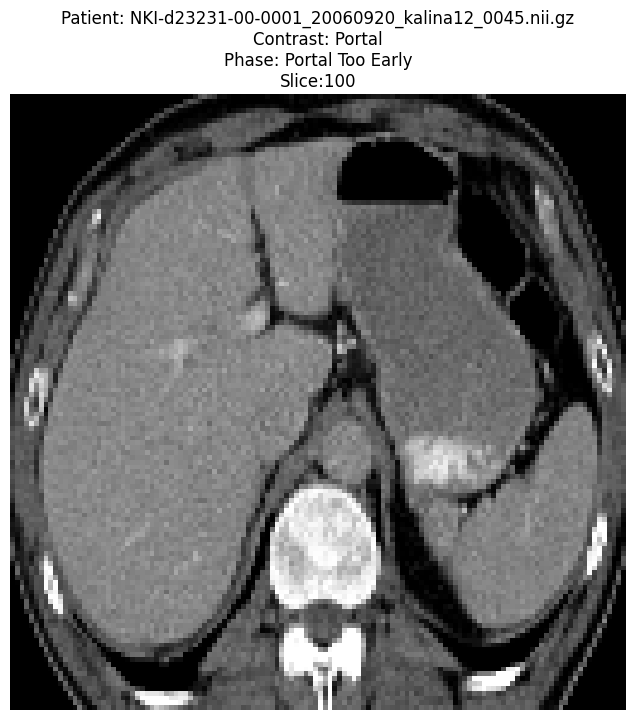

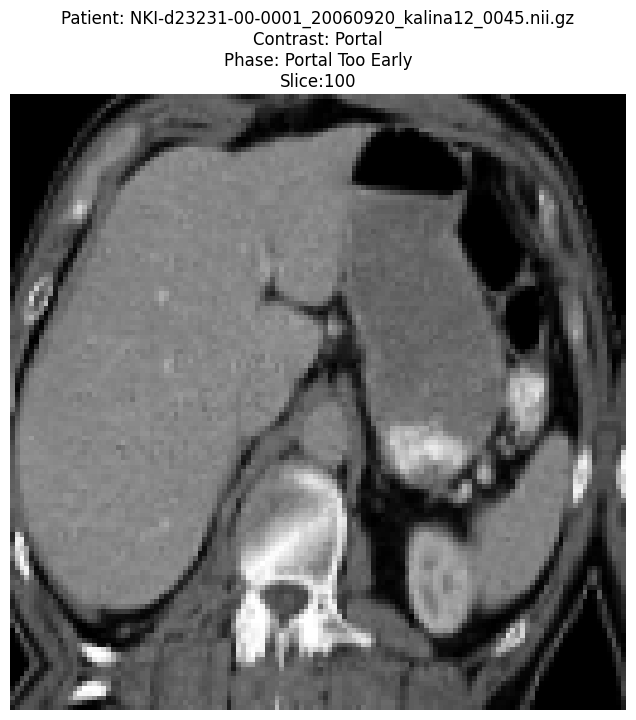

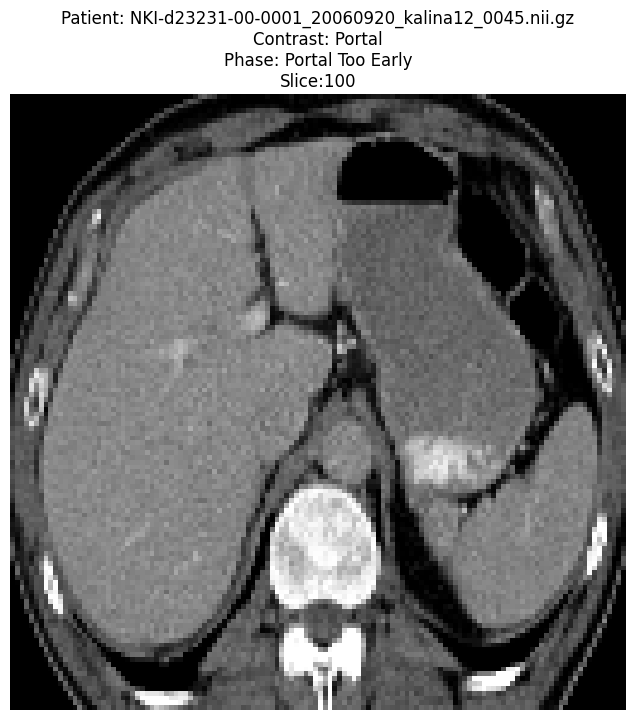

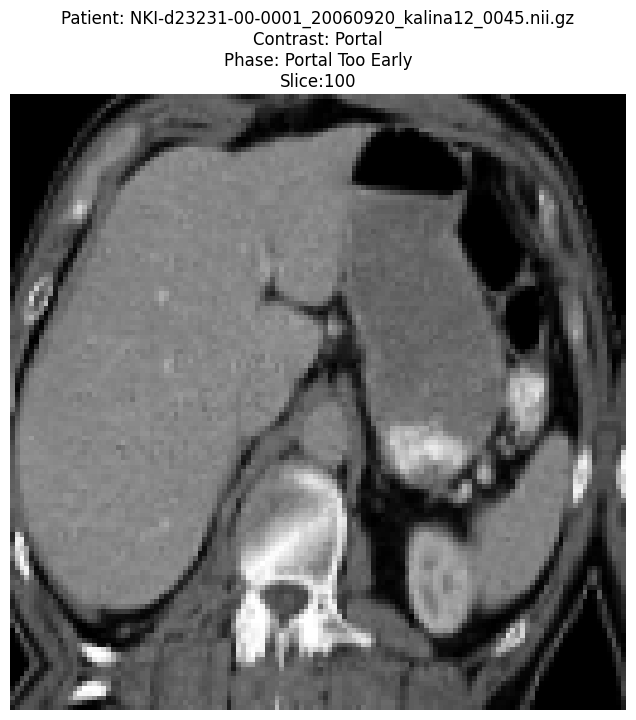

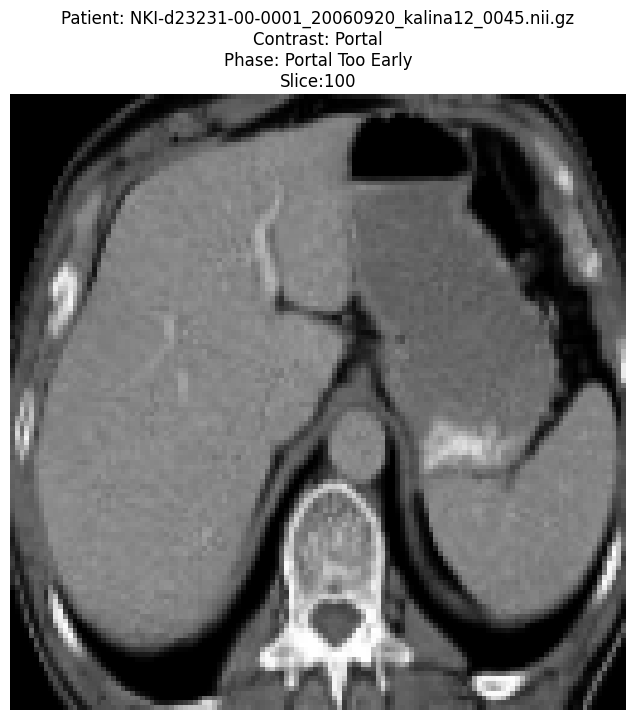

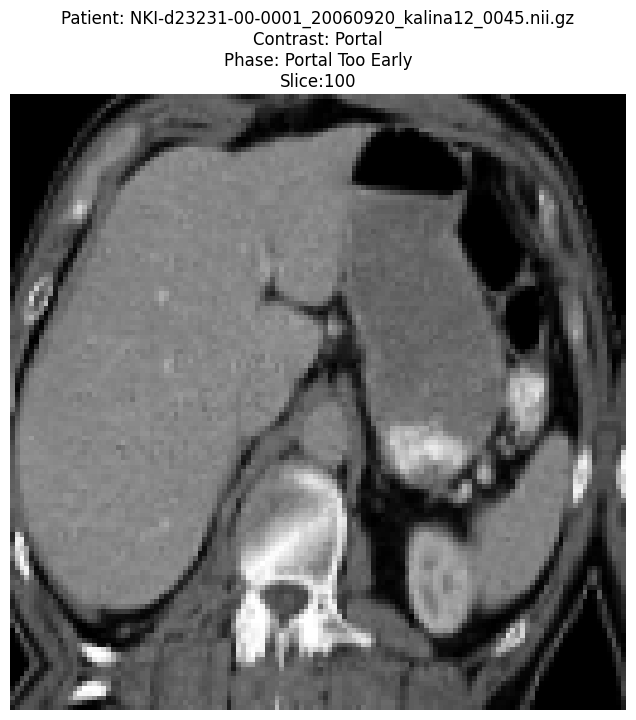

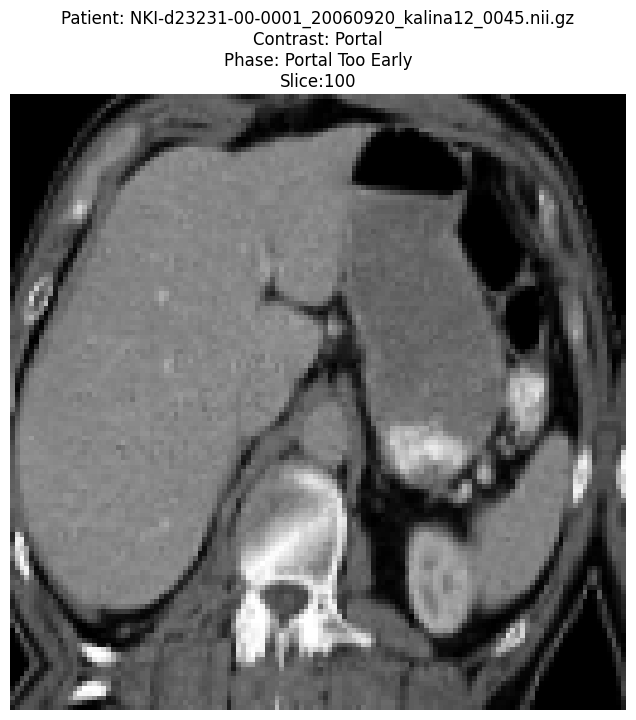

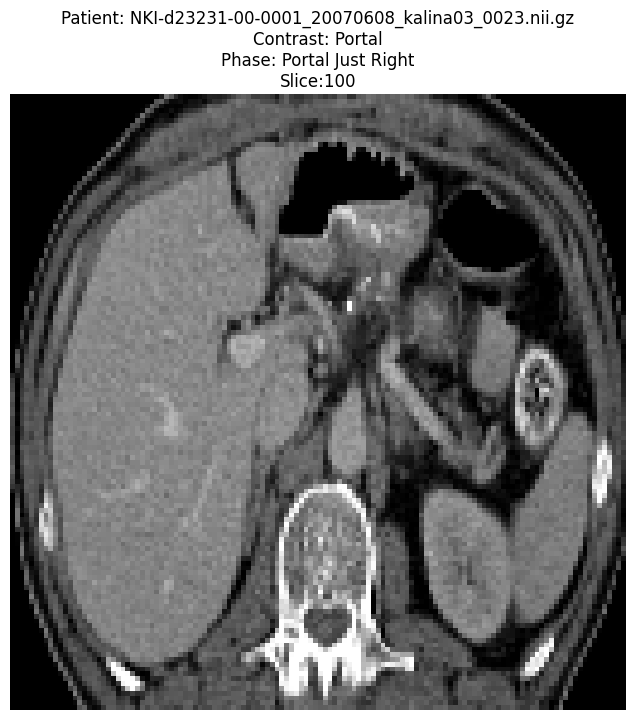

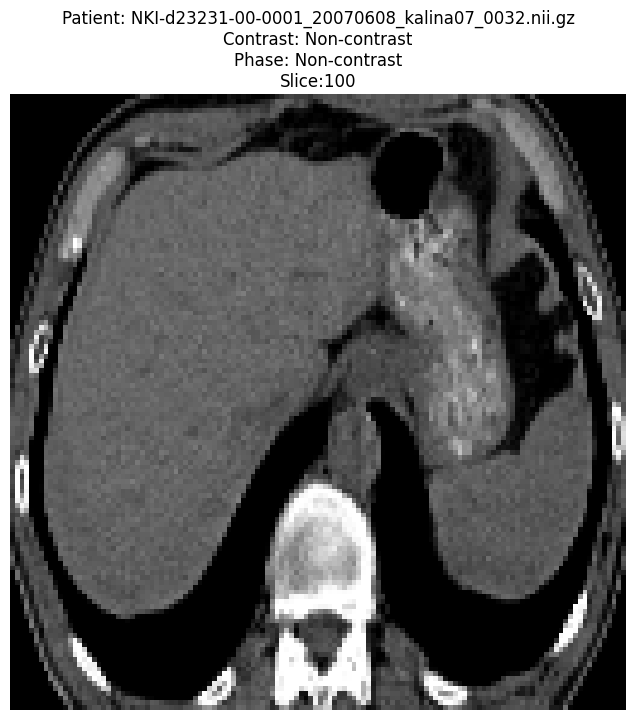

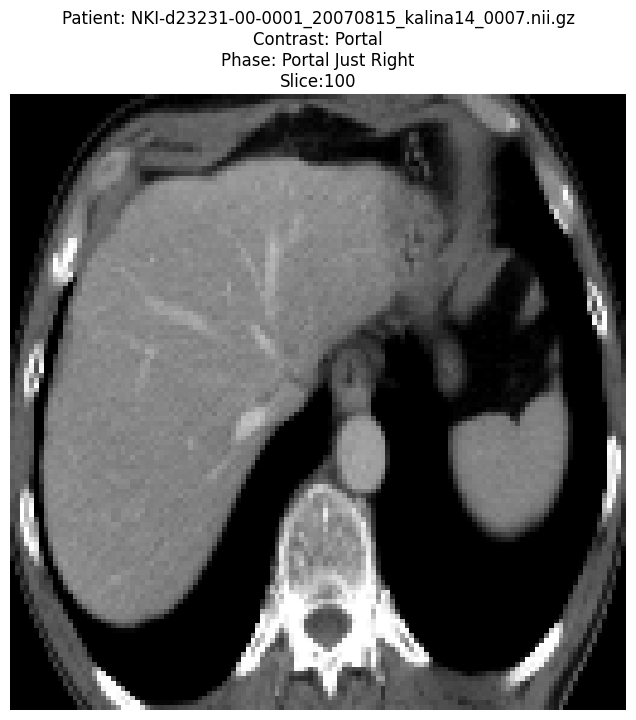

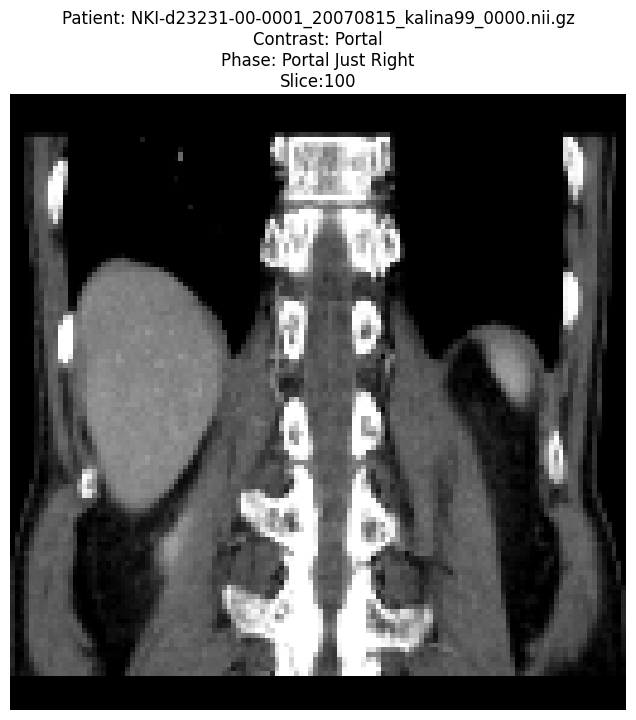

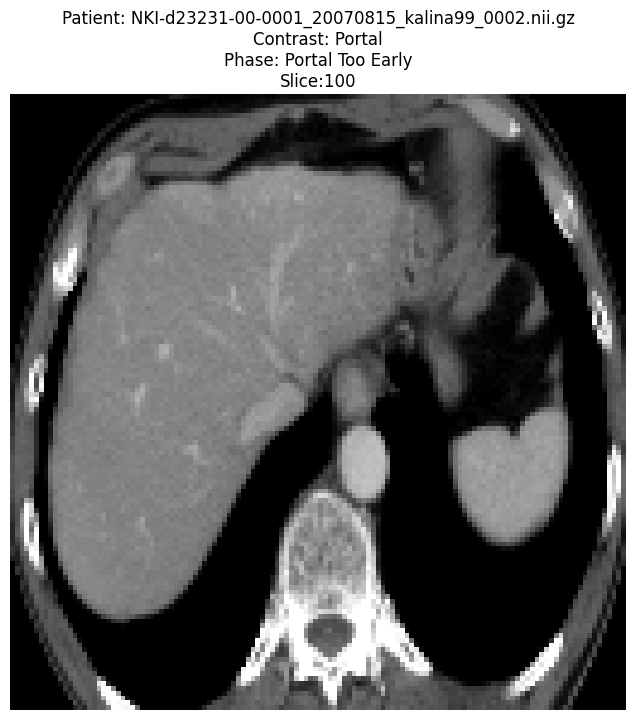

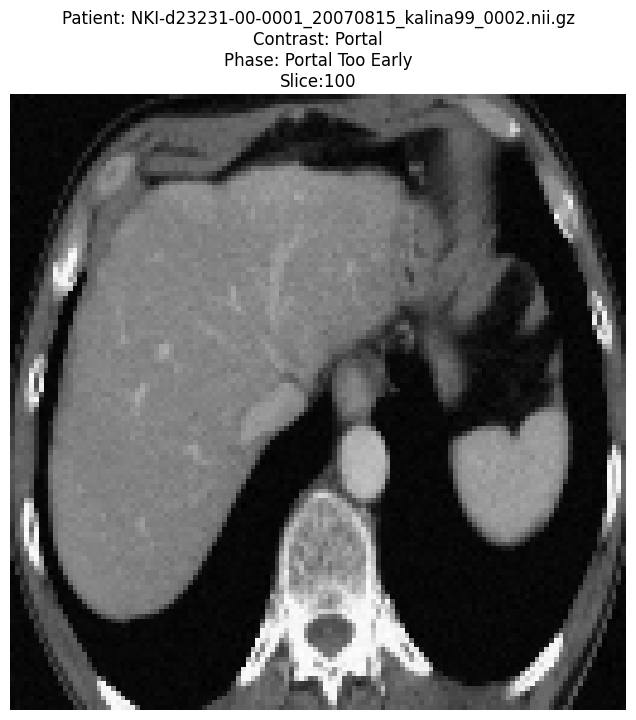

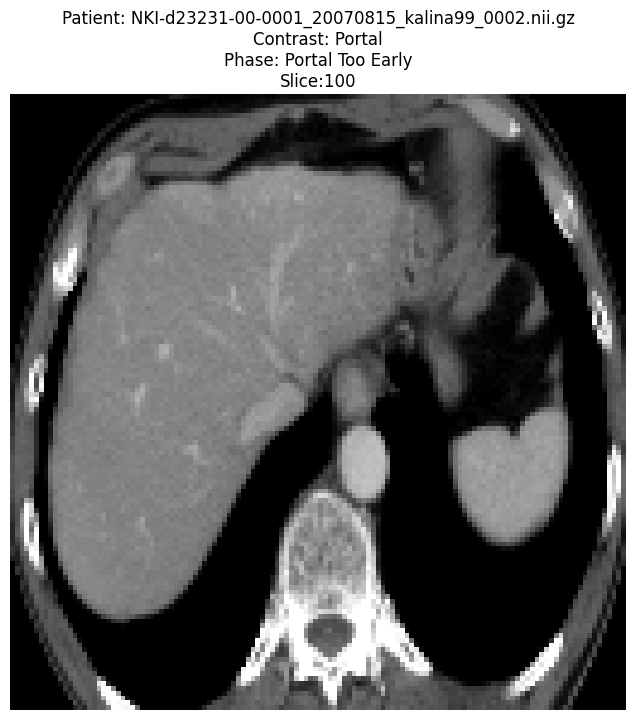

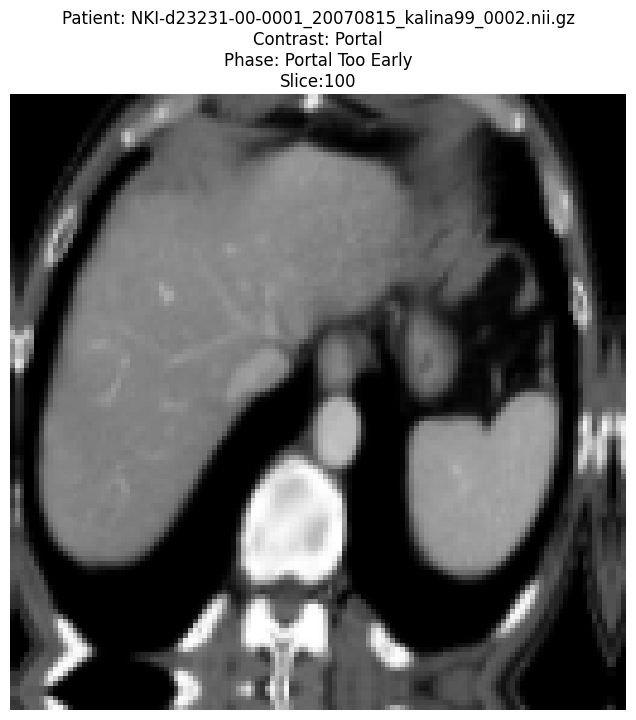

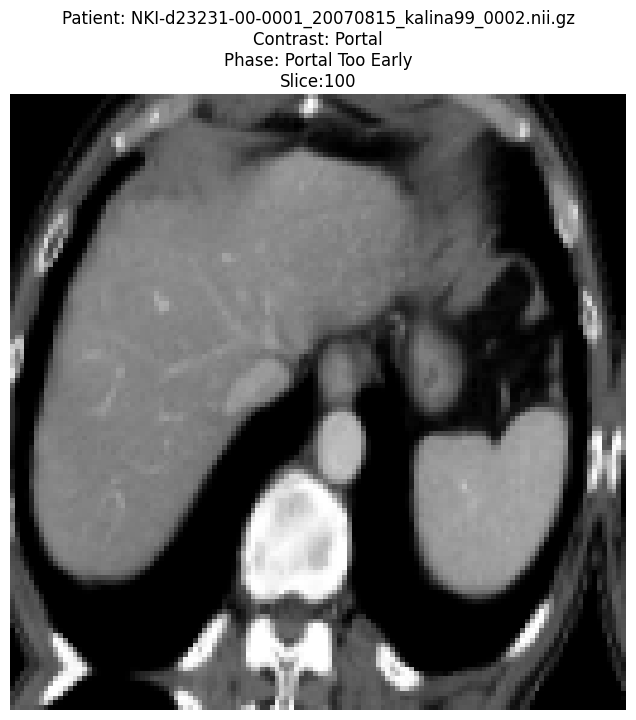

In [2]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_preprocessed/train"

def load_dataset(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".pt")])

    dataset = []
    i = 0
    while i < min(20, len(files)):
        f = files[i]
        data = torch.load(os.path.join(folder, f))
        dataset.append((data['patient_id'], data['key'], data["image"], data["contrast"], data['phase']))
        i += 1

    return dataset

data = load_dataset(folder)

slice = 100
for i in range(len(data)):
    image = data[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {data[i][1]}\nContrast: {data[i][3]}\nPhase: {data[i][4]}\nSlice:{slice}")
    plt.axis("off")

/tmp/ipykernel_3666839/3922809034.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(folder, f))


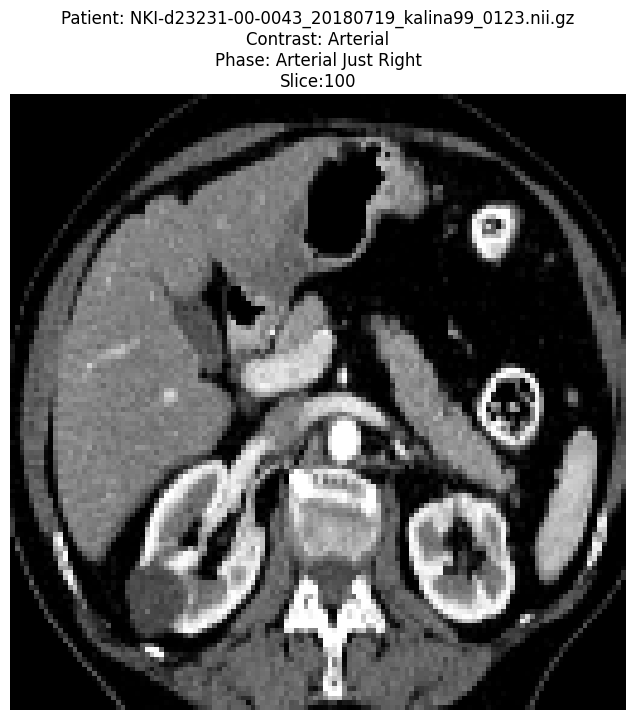

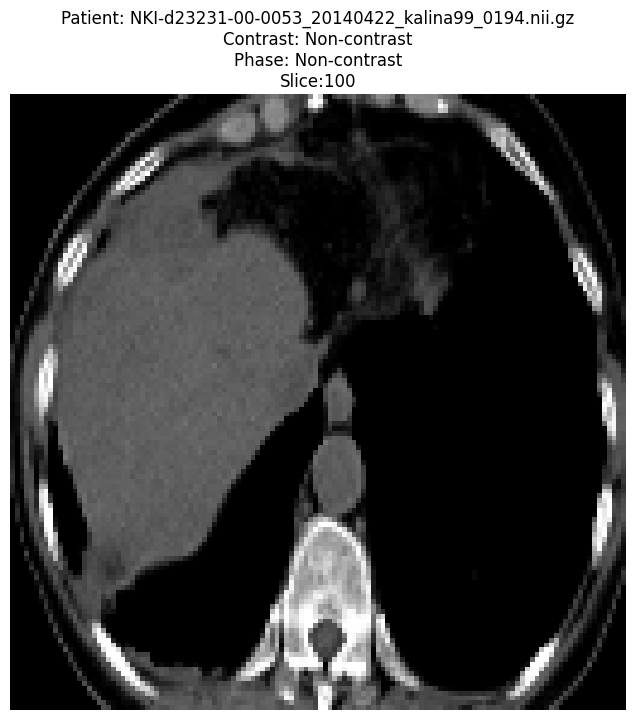

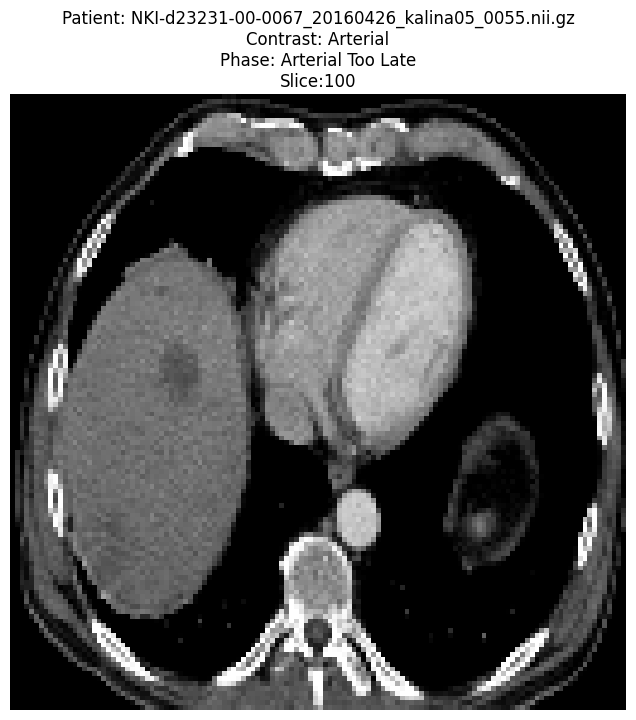

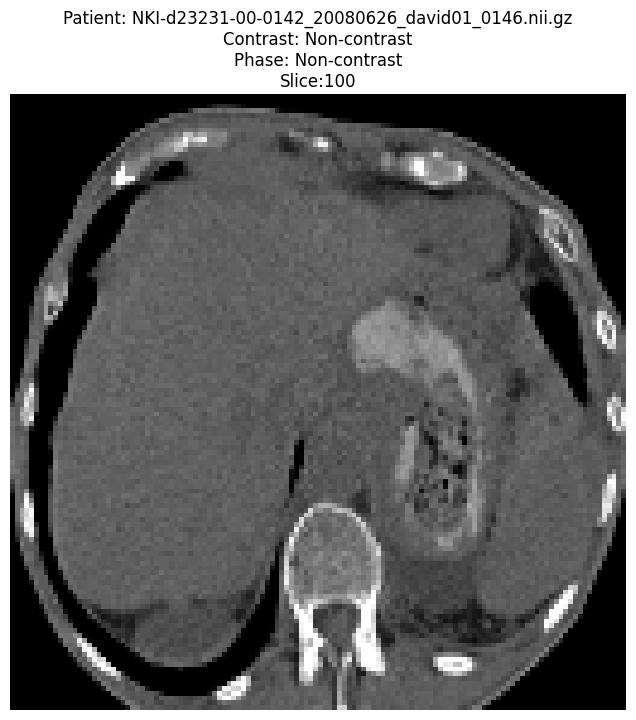

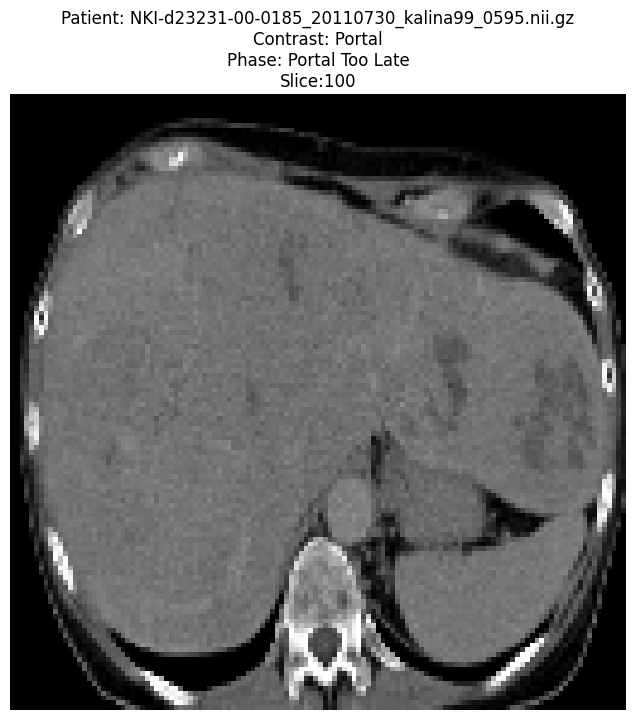

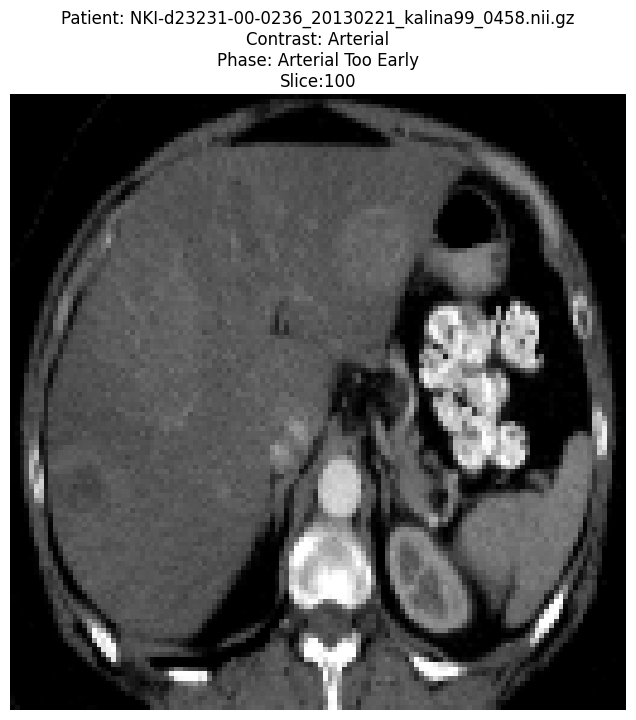

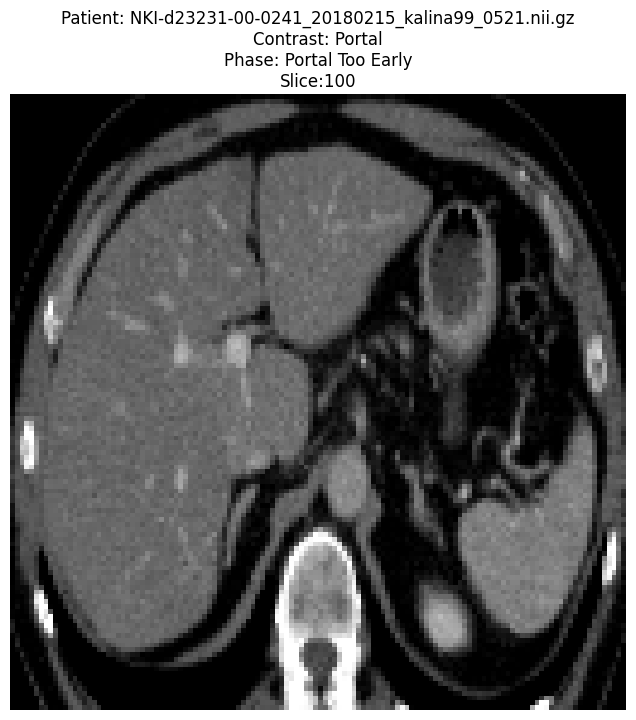

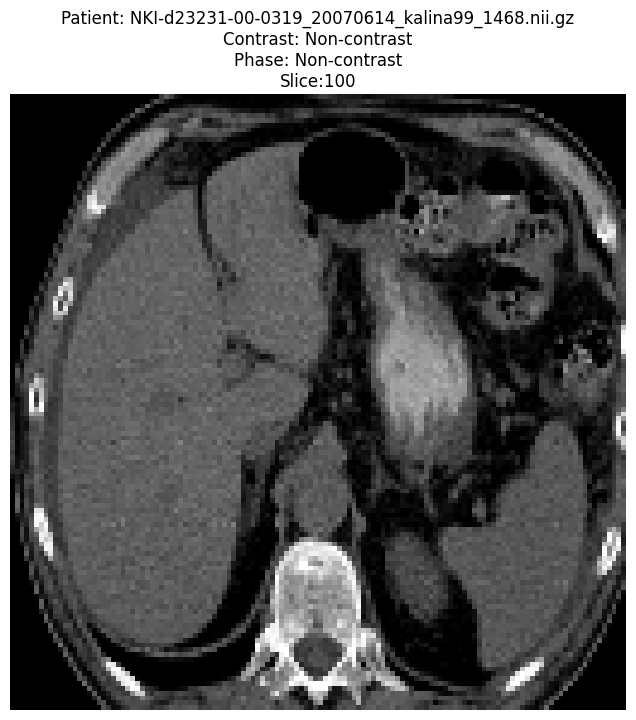

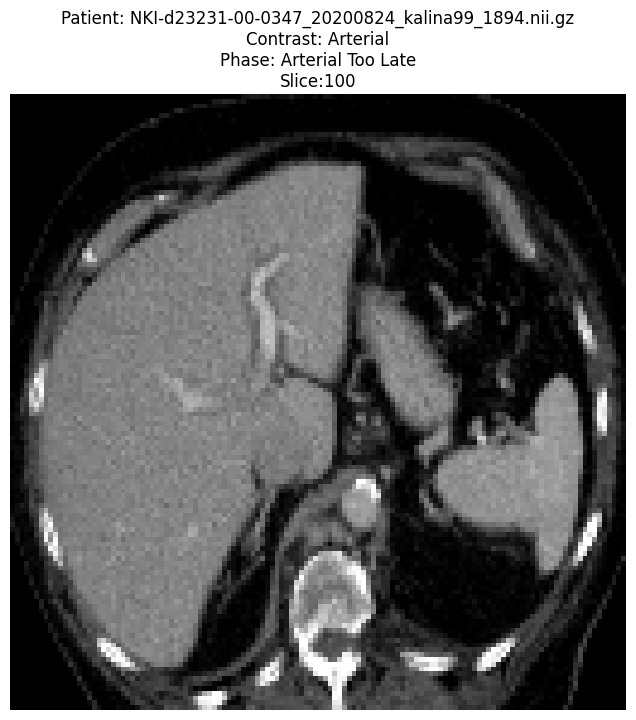

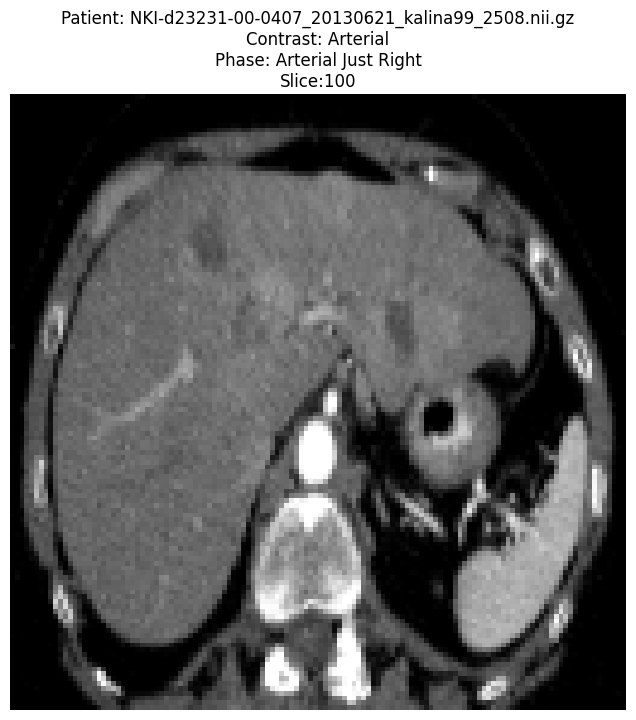

In [ ]:
folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/contrast_preprocessed/val"

def load_dataset(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".pt")])

    dataset = []
    i = 0
    while i < min(10, len(files)):
        f = files[i]
        data = torch.load(os.path.join(folder, f))
        dataset.append((data['patient_id'], data['key'], data["image"], data["contrast"], data['phase']))
        i += 1

    return dataset

data = load_dataset(folder)
slice = 100
for i in range(len(data)):
    image = data[i][2]
    plt.figure(figsize=(10,8))
    plt.imshow((np.rot90(image[0, :, :, slice], k=1)), cmap="gray")
    plt.title(f"Patient: {data[i][1]}\nContrast: {data[i][3]}\nPhase: {data[i][4]}\nSlice:{slice}")
    plt.axis("off")

# Inspect processed data

## Contrast data

In [3]:
contrast_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Contrast_data/preprocessed_data.csv")
contrast_data

,Unnamed: 0,SubjectKeyRadiology,ExamDate,MatchKey,contrast,phase,image_file,organ_file,rare_class,split,augment,output_dir,base_name,output_path
0,0,NKI-d23231-00-0063,2012-04-16,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,Arterial,Arterial Too Early,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,val,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0063_20120416_kalina01_0000,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
1,1,NKI-d23231-00-0070,2015-08-21,NKI-d23231-00-0070_20150821_kalina01_0001.nii.gz,Non-contrast,Non-contrast,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0070_20150821_kalina01_0001,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
2,2,NKI-d23231-00-0036,2014-02-18,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,Portal,Portal Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,test,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0036_20140218_kalina01_0002,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
3,3,NKI-d23231-00-0071,2013-09-24,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,Arterial,Arterial Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0071_20130924_kalina01_0003,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
4,4,NKI-d23231-00-0077,2014-12-22,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,Portal,Portal Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0077_20141222_kalina01_0004,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8134,8134,NKI-d23231-00-0888,2022-04-20,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,Portal,Portal Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_20220420_kalina99_5827,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
8135,8135,NKI-d23231-00-0888,2023-04-24,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,Arterial,Arterial Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_20230424_kalina99_5828,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
8136,8136,NKI-d23231-00-0888,2023-04-24,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,Portal,Portal Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_20230424_kalina99_5829,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
8137,8137,NKI-d23231-00-0888,2023-08-01,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,Arterial,Arterial Just Right,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0,train,0,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_20230801_kalina99_5830,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...


## Time interval data

In [2]:
time_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/Preprocessing/Time_interval_data/paired_preprocessed_data.csv")
time_data

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,arterial_organs,portal_organs,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path
0,NKI-d23231-00-0002,2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,0.00519,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0002_2015-12-01,0,NKI-d23231-00-0002_2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
1,NKI-d23231-00-0005,2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,53.64779,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2010-02-04,0,NKI-d23231-00-0005_2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
2,NKI-d23231-00-0005,2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,33.40000,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2012-06-18,0,NKI-d23231-00-0005_2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
3,NKI-d23231-00-0005,2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,30.84280,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2022-05-11,0,NKI-d23231-00-0005_2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
4,NKI-d23231-00-0005,2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,32.75200,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0005_2022-10-17,0,NKI-d23231-00-0005_2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1674,NKI-d23231-00-0887,2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,31.57800,val,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0887_2023-05-24,0,NKI-d23231-00-0887_2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
1675,NKI-d23231-00-0887,2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,28.90000,val,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0887_2023-08-30,0,NKI-d23231-00-0887_2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
1676,NKI-d23231-00-0888,2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,31.78189,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_2022-04-20,0,NKI-d23231-00-0888_2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
1677,NKI-d23231-00-0888,2023-04-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,34.57700,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0888_2023-04-24,0,NKI-d23231-00-0888_2023-04-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...


In [3]:
import seaborn as sns

print(time_data["time_interval"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(time_data["time_interval"], bins=50, kde=True)
plt.xlabel("Time Interval")
plt.title("Time Interval Distribution")
plt.show()

plt.figure(figsize=(6, 3))
plt.boxplot(time_data["time_interval"], vert=False)
plt.xlabel("Time Interval")
plt.title("Boxplot of Time Interval")
plt.show()

KeyboardInterrupt: 

In [ ]:
col = "time_interval"

Q1 = time_data[col].quantile(0.25)
Q3 = time_data[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = time_data[(time_data[col] < lower_bound) | (time_data[col] > upper_bound)]

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage: {len(outliers) / len(time_data) * 100:.2f}%")

Lower bound: -2.7185300000055435
Upper bound: 90.71771000000442
Number of outliers: 22
Percentage: 1.31%


In [ ]:
outliers

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,arterial_organs,portal_organs,time_interval,split,output_dir,base_name_raw,dups_count,base_name,output_path
28,NKI-d23231-00-0026,2007-07-23,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,107.00000,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0026_2007-07-23,1,NKI-d23231-00-0026_2007-07-23_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
64,NKI-d23231-00-0043,2007-05-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,126.00000,test,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0043_2007-05-01,1,NKI-d23231-00-0043_2007-05-01_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
238,NKI-d23231-00-0078,2013-09-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,92.30000,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0078_2013-09-04,0,NKI-d23231-00-0078_2013-09-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
326,NKI-d23231-00-0109,2006-12-14,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,288.51576,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0109_2006-12-14,0,NKI-d23231-00-0109_2006-12-14,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
358,NKI-d23231-00-0134,2009-03-19,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,95.34062,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0134_2009-03-19,0,NKI-d23231-00-0134_2009-03-19,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
391,NKI-d23231-00-0146,2006-09-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,125.20817,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0146_2006-09-20,0,NKI-d23231-00-0146_2006-09-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
405,NKI-d23231-00-0149,2007-03-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,143.00028,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0149_2007-03-20,1,NKI-d23231-00-0149_2007-03-20_1,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
463,NKI-d23231-00-0167,2008-04-02,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,113.71147,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0167_2008-04-02,0,NKI-d23231-00-0167_2008-04-02,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
470,NKI-d23231-00-0169,2017-05-16,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,121.65808,train,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,NKI-d23231-00-0169_2017-05-16,0,NKI-d23231-00-0169_2017-05-16,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...
519,NKI-d23231-00-0183,2013-04-25,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/A

/tmp/ipykernel_2846906/4098356900.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_data = torch.load(f)


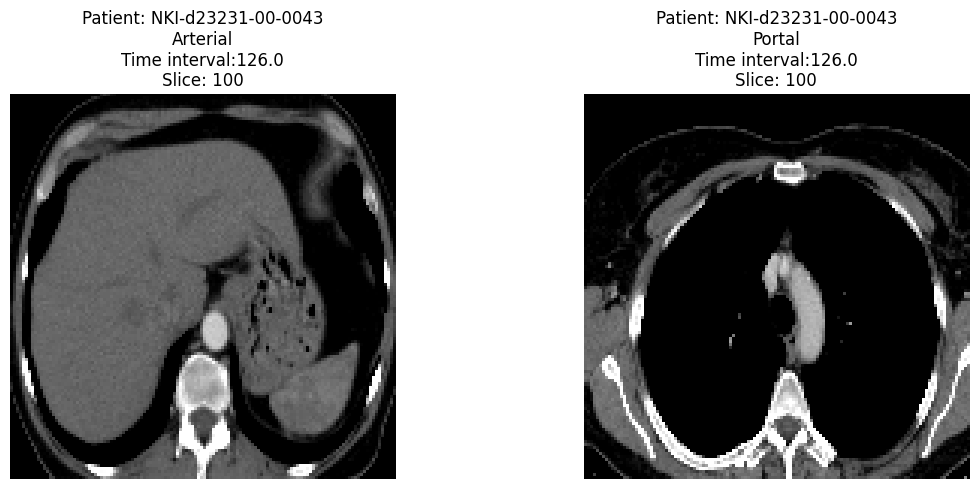

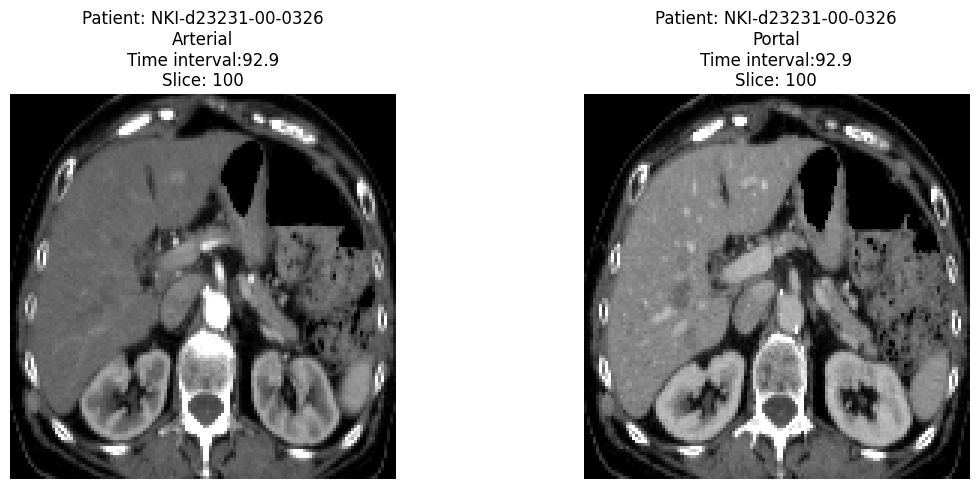

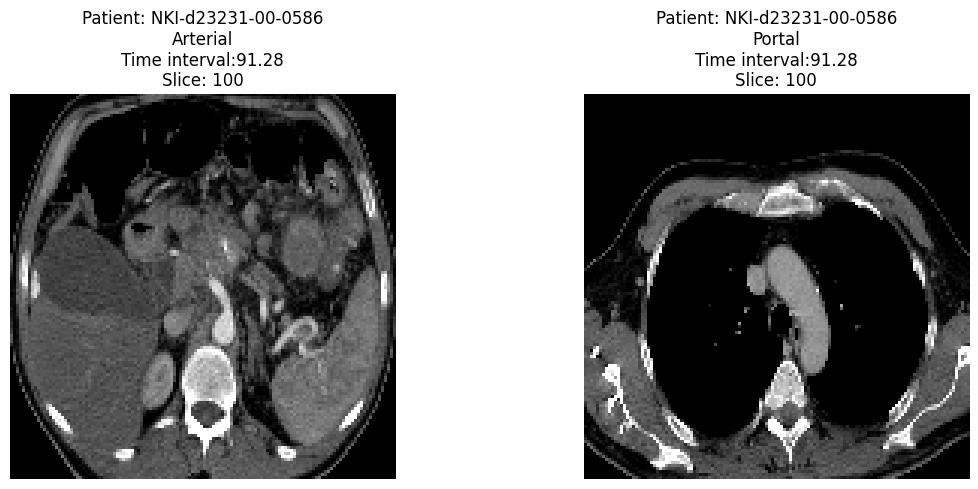

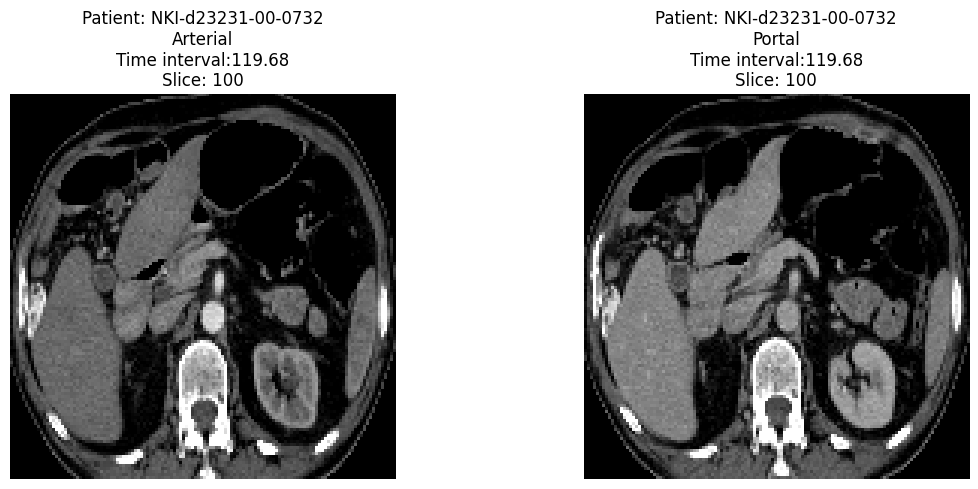

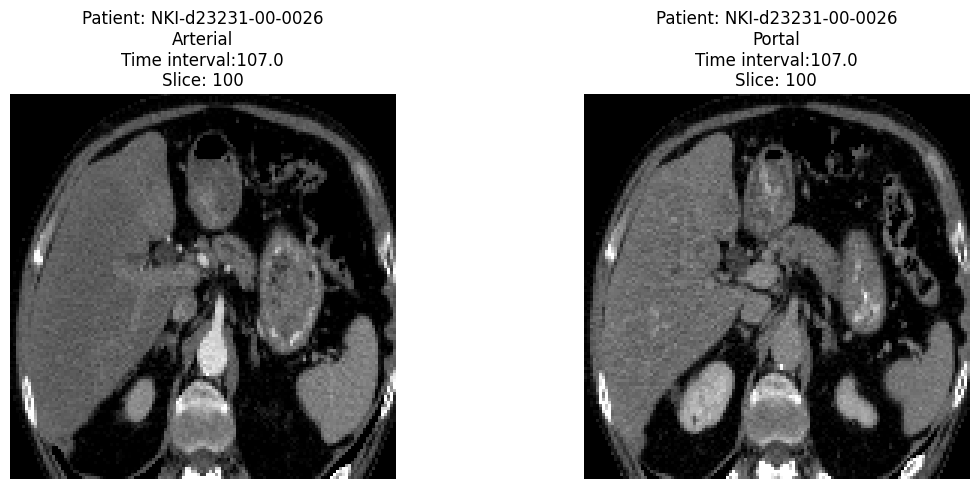

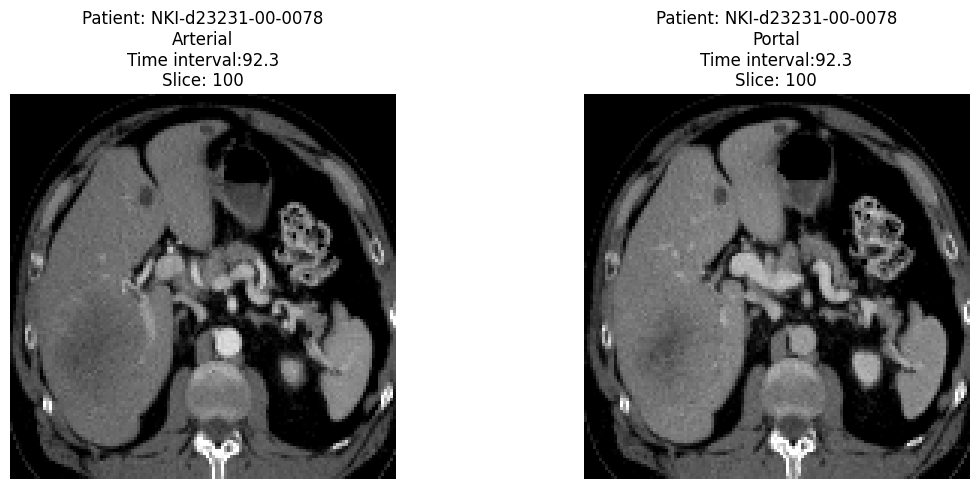

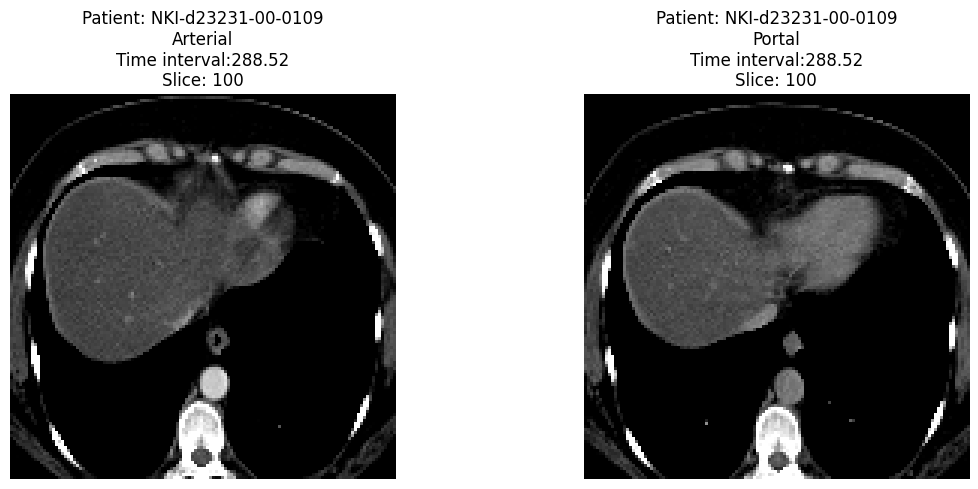

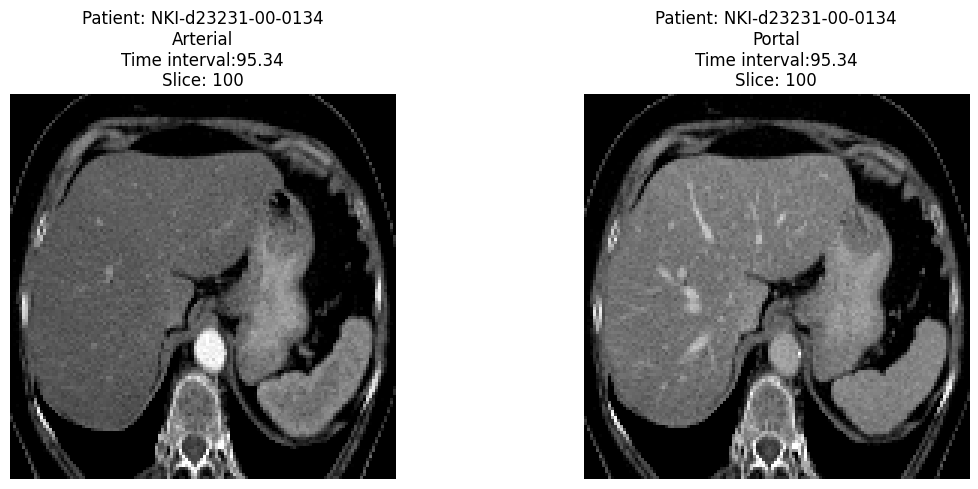

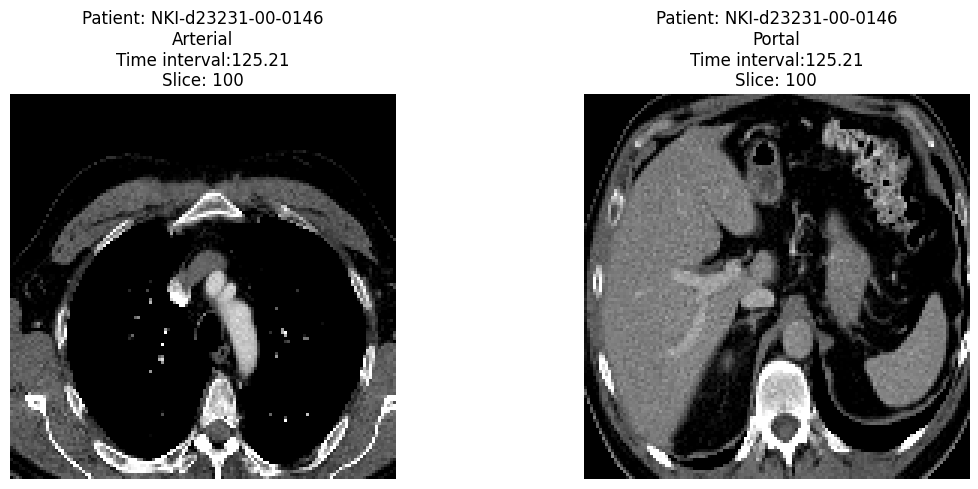

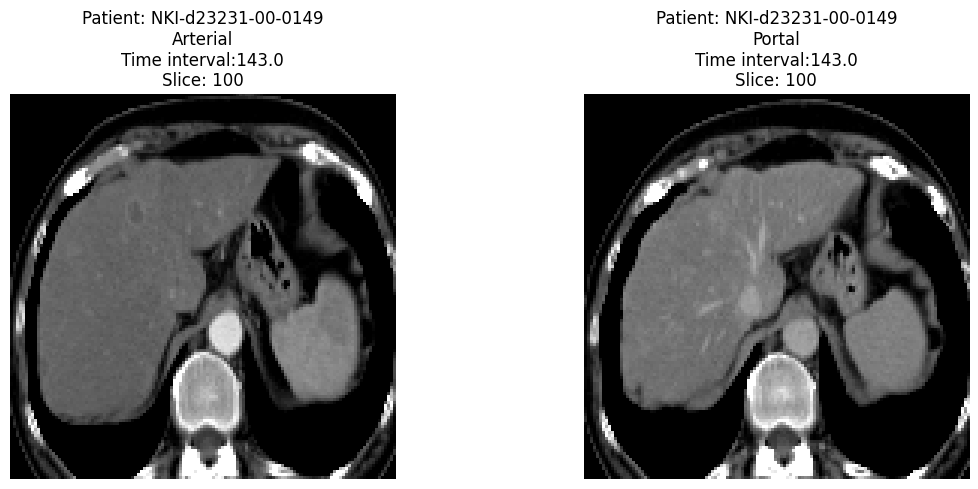

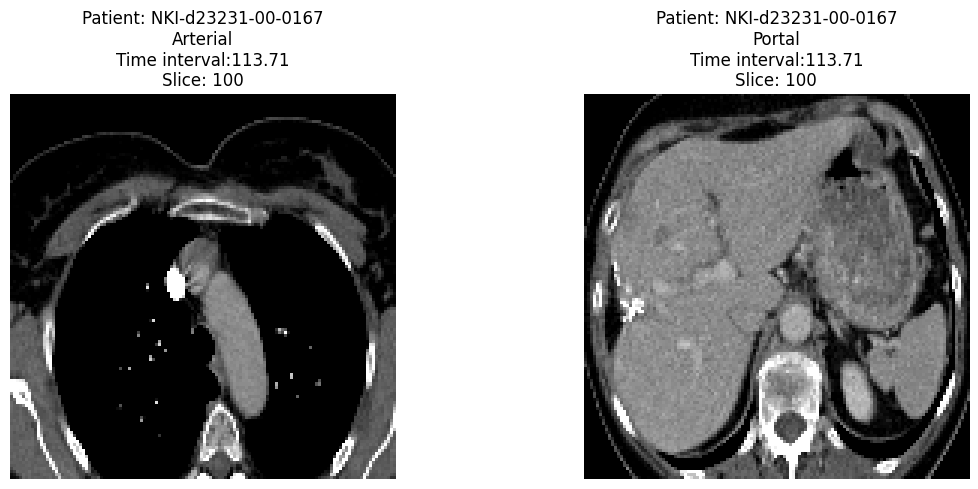

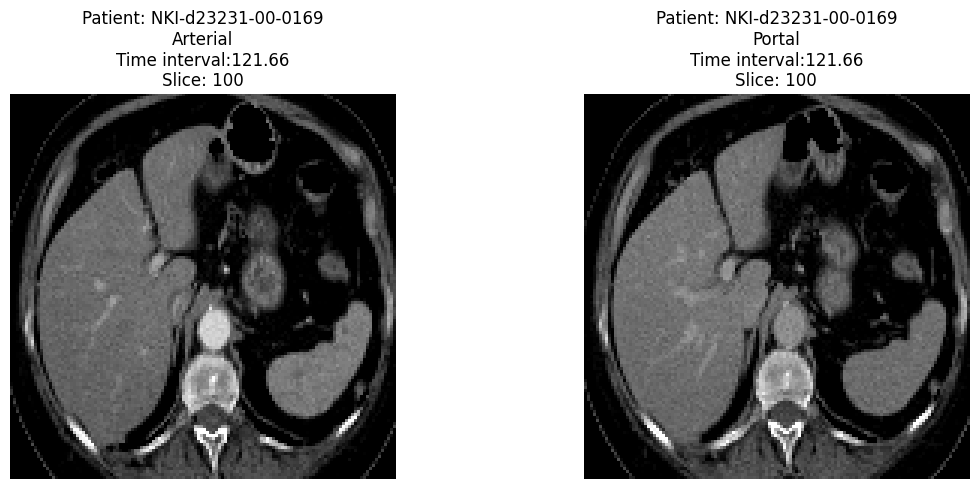

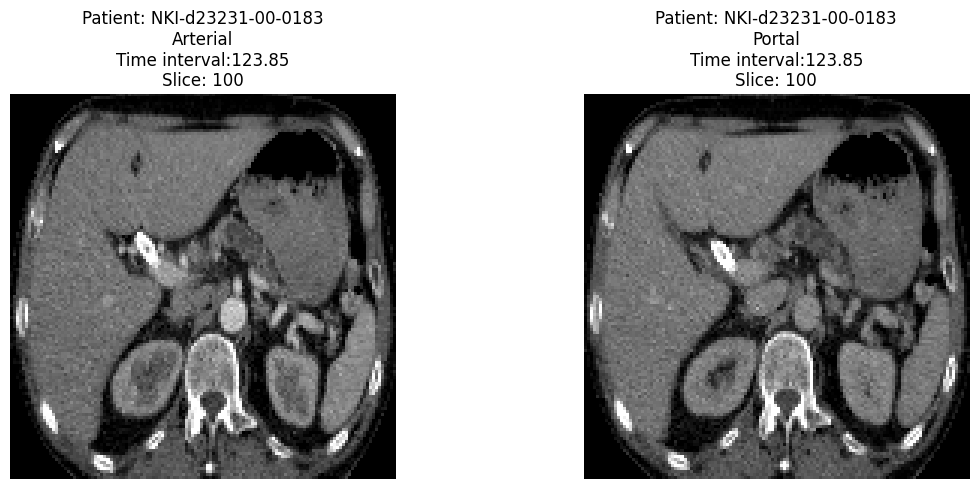

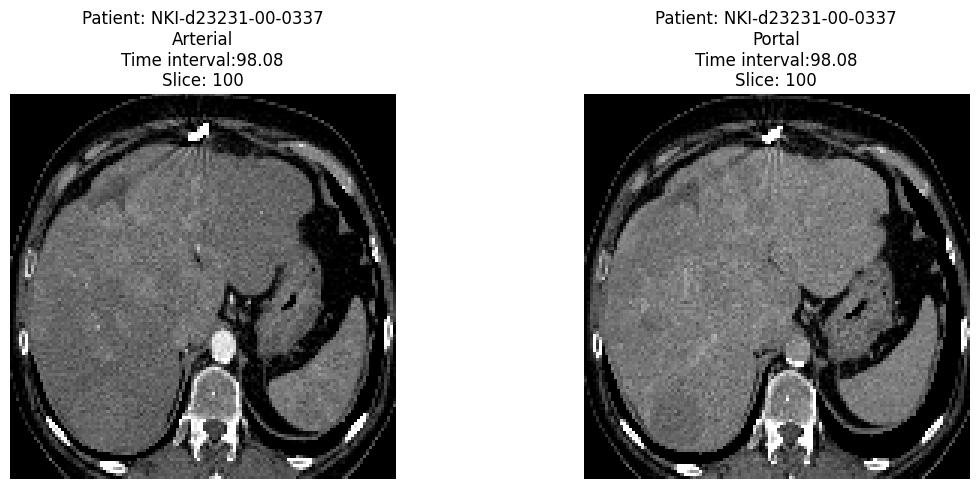

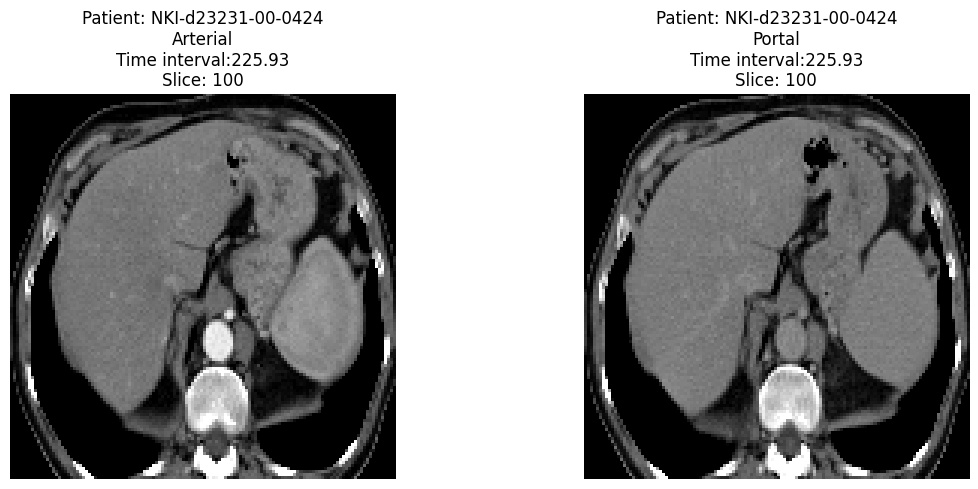

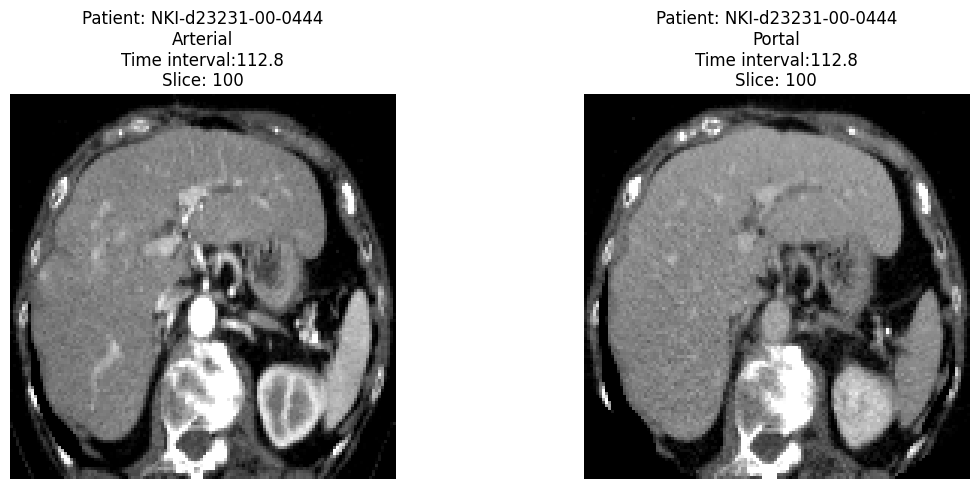

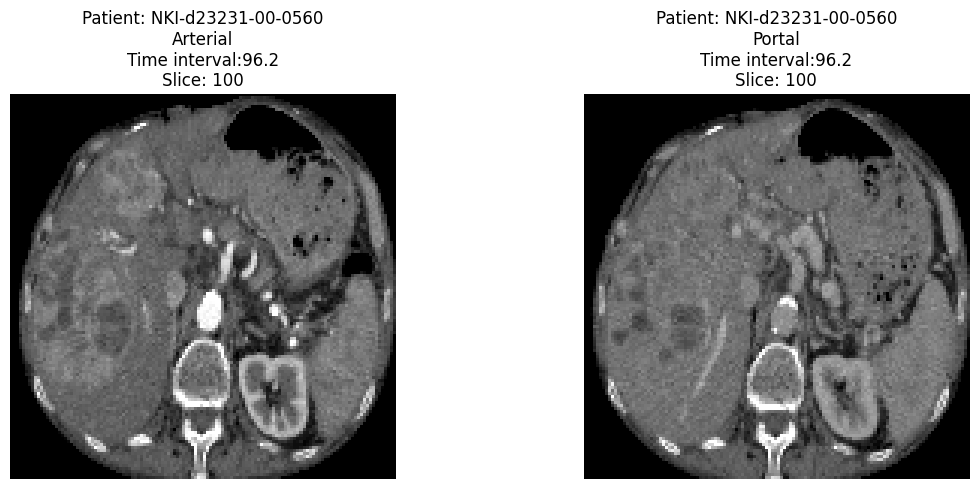

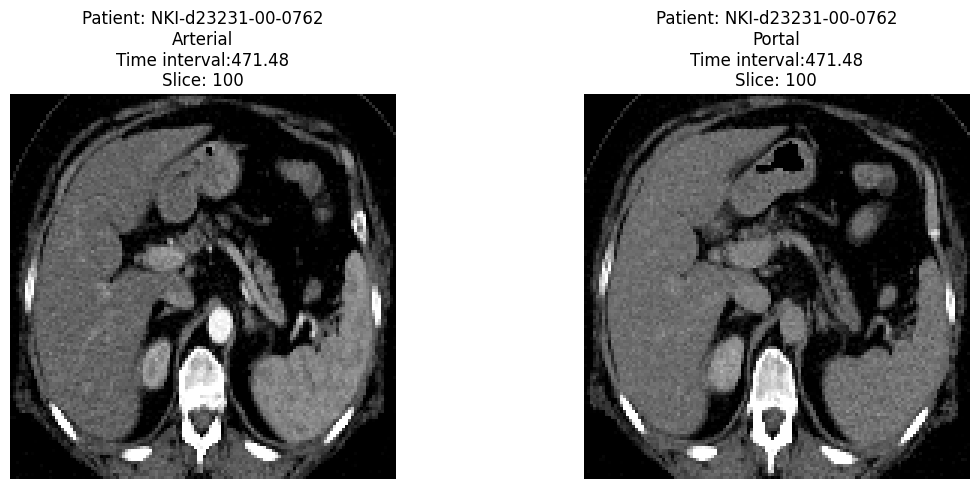

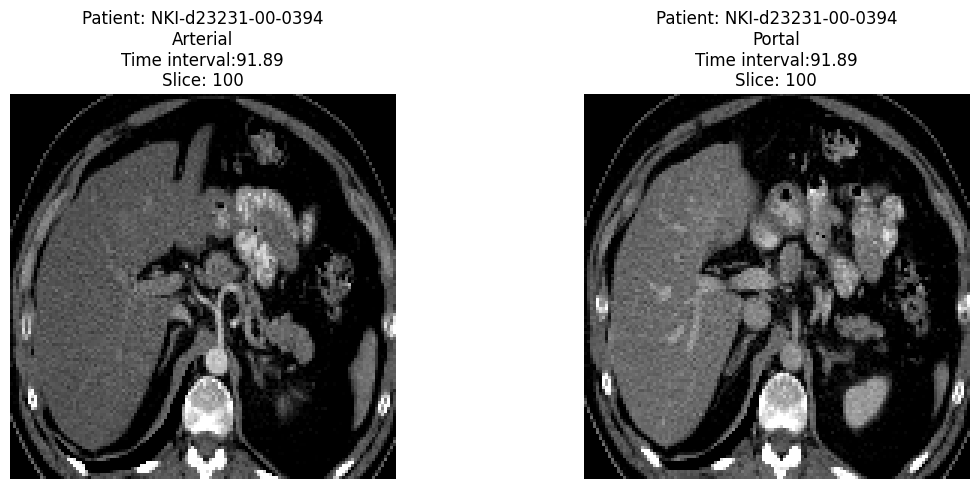

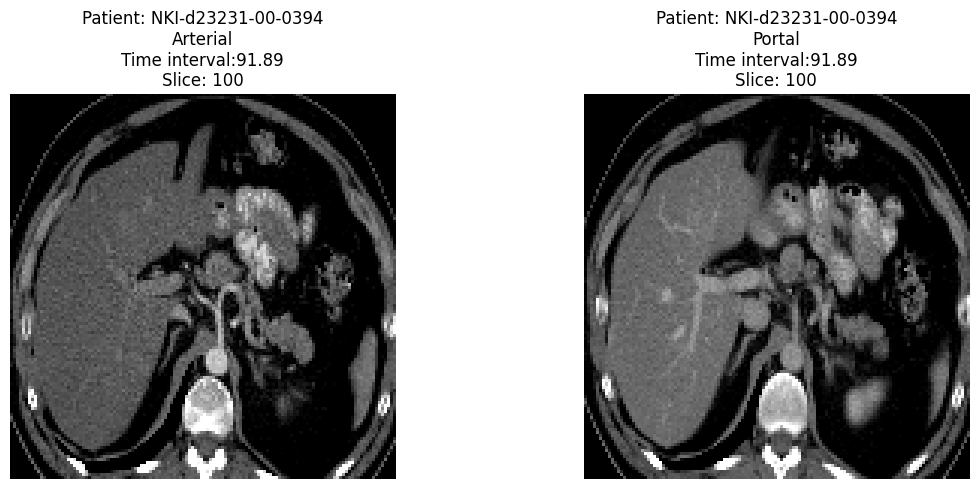

In [ ]:
def load_dataset(data):
    files = sorted([f for f in data.output_path])

    dataset = []
    i = 0

    while i < min(20, len(files)):
        f = files[i]
        image_data = torch.load(f)
        dataset.append((image_data["patient_id"], image_data['arterial_image'], image_data['portal_image'], image_data["time_interval"]))
        i += 1

    return dataset

data = load_dataset(outliers)

slice_idx = 100

for i in range(len(data)):
    patient_id, arterial, portal, interval = data[i]

    plt.figure(figsize=(12, 5))

    # Arterial
    plt.subplot(1, 2, 1)
    plt.imshow(np.rot90(arterial[0, :, :, slice_idx], k=1), cmap="gray")
    plt.title(f"Patient: {patient_id}\nArterial\nTime interval:{round(interval, 2)}\nSlice: {slice_idx}")
    plt.axis("off")

    # Portal
    plt.subplot(1, 2, 2)
    plt.imshow(np.rot90(portal[0, :, :, slice_idx], k=1), cmap="gray")
    plt.title(f"Patient: {patient_id}\nPortal\nTime interval:{round(interval, 2)}\nSlice: {slice_idx}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## Radiomics data for encoding

In [4]:
import sys
sys.path.append("/projects/net_contrast_classification/contrast_phase")
from Radiomics.data_preprocessing import radiomics_load, preprocess_train, preprocess_test

data_dir = Path("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")
features_dir = Path("/projects/net_contrast_classification/contrast_phase/Radiomics/features")

radiomics = radiomics_load(data_dir, features_dir)
radiomics

,image,SubjectKeyRadiology,phase_timing,contrast,organ,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glcm_Correlation,original_glcm_Autocorrelation,original_glcm_ClusterTendency,original_glcm_DifferenceEntropy,original_glszm_ZoneEntropy,original_glszm_SmallAreaEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_SizeZoneNonUniformity,original_gldm_SmallDependenceEmphasis,original_gldm_DependenceNonUniformity
0,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,spleen,73.0,129.0,1.411073e+09,2.345055,28.0,...,0.331391,161.467821,4.317435,1.807917,5.579062,0.607571,789.747481,2234.026508,0.057494,8059.752032
1,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,kidney_right,35.0,174.0,2.051722e+09,3.368361,96.0,...,0.573631,172.405745,24.124352,2.463745,5.972511,0.623694,1069.817432,4300.504964,0.100165,11505.342655
2,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,kidney_left,29.0,175.0,1.875893e+09,3.462463,101.0,...,0.625287,168.789858,27.864372,2.459546,5.964703,0.651090,921.112624,4496.306967,0.102064,10496.241509
3,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,gallbladder,15.0,92.0,6.779767e+06,2.671679,44.0,...,0.277793,49.512989,6.008309,2.088526,5.214034,0.571997,22.650794,58.957672,0.102627,169.717503
4,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,liver,57.0,111.0,9.182282e+09,2.273400,28.0,...,0.304811,769.295507,3.639820,1.789879,5.516856,0.589709,7598.796877,15753.440790,0.049232,79966.681546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166655,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,portal_vein_and_splenic_vein,94.0,199.0,3.244518e+08,2.985268,54.0,...,0.441004,162.569181,11.146397,2.231316,5.916112,0.579998,180.277874,546.459272,0.132850,1009.163186
166656,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_artery_left,47.0,169.0,1.198564e+08,3.299687,60.0,...,0.538260,169.284619,19.404490,2.269254,6.271613,0.553009,87.013220,307.181303,0.143030,577.424611
166657,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_artery_right,47.0,167.0,2.443429e+08,3.426126,67.0,...,0.574321,193.314195,96.147512,2.481168,6.542065,0.607940,99.914074,464.976296,0.155215,700.690310
166658,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_vena_left,26.0,122.0,1.316743e+08,3.136003,42.0,...,0.626491,113.830952,18.455433,2.138249,6.222564,0.600864,131.003509,578.122807,0.110335,1047.527077


In [5]:
radiomics.info()

<class 'pandas.DataFrame'>
RangeIndex: 166660 entries, 0 to 166659
Data columns (total 34 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   image                                            166660 non-null  str    
 1   SubjectKeyRadiology                              166660 non-null  str    
 2   phase_timing                                     166660 non-null  str    
 3   contrast                                         166660 non-null  str    
 4   organ                                            166660 non-null  str    
 5   original_firstorder_10Percentile                 146636 non-null  float64
 6   original_firstorder_90Percentile                 146636 non-null  float64
 7   original_firstorder_Energy                       146636 non-null  float64
 8   original_firstorder_Entropy                      146636 non-null  float64
 9   original_firstorder_Interq

In [6]:
time_pairs = time_data[["SubjectKeyRadiology", "ExamDate", "arterial_file", "portal_file", "split"]]
time_pairs

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,split
0,NKI-d23231-00-0002,2015-12-01,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,test
1,NKI-d23231-00-0005,2010-02-04,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,train
2,NKI-d23231-00-0005,2012-06-18,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,train
3,NKI-d23231-00-0005,2022-05-11,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,train
4,NKI-d23231-00-0005,2022-10-17,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,train
...,...,...,...,...,...
1674,NKI-d23231-00-0887,2023-05-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,val
1675,NKI-d23231-00-0887,2023-08-30,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,val
1676,NKI-d23231-00-0888,2022-04-20,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,train
1677,NKI-d23231-00-0888,2023-04-24,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTI...,train


In [7]:
time_pairs.arterial_file.iloc[0]

'/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz'

In [8]:
time_pairs["arterial_file"] = time_pairs["arterial_file"].apply(lambda x: PureWindowsPath(x).name)
time_pairs["portal_file"] = time_pairs["portal_file"].apply(lambda x: PureWindowsPath(x).name)

time_pairs

,SubjectKeyRadiology,ExamDate,arterial_file,portal_file,split
0,NKI-d23231-00-0002,2015-12-01,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002_20151201_kalina04_0039.nii.gz,test
1,NKI-d23231-00-0005,2010-02-04,NKI-d23231-00-0005_20100204_kalina04_0000.nii.gz,NKI-d23231-00-0005_20100204_kalina99_0007.nii.gz,train
2,NKI-d23231-00-0005,2012-06-18,NKI-d23231-00-0005_20120618_kalina12_0050.nii.gz,NKI-d23231-00-0005_20120618_kalina99_0009.nii.gz,train
3,NKI-d23231-00-0005,2022-05-11,NKI-d23231-00-0005_20220511_kalina99_0013.nii.gz,NKI-d23231-00-0005_20220511_kalina01_0056.nii.gz,train
4,NKI-d23231-00-0005,2022-10-17,NKI-d23231-00-0005_20221017_kalina02_0055.nii.gz,NKI-d23231-00-0005_20221017_kalina99_0015.nii.gz,train
...,...,...,...,...,...
1674,NKI-d23231-00-0887,2023-05-24,NKI-d23231-00-0887_20230524_kalina99_5820.nii.gz,NKI-d23231-00-0887_20230524_kalina99_5818.nii.gz,val
1675,NKI-d23231-00-0887,2023-08-30,NKI-d23231-00-0887_20230830_kalina99_5821.nii.gz,NKI-d23231-00-0887_20230830_kalina99_5822.nii.gz,val
1676,NKI-d23231-00-0888,2022-04-20,NKI-d23231-00-0888_20220420_kalina99_5826.nii.gz,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,train
1677,NKI-d23231-00-0888,2023-04-24,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,train


In [9]:
time_pairs_long = time_pairs.melt(
                            id_vars=["SubjectKeyRadiology", "ExamDate", "split"],
                            value_vars=["arterial_file", "portal_file"],
                            var_name="phase",
                            value_name="image"
                        )


time_pairs_long

,SubjectKeyRadiology,ExamDate,split,phase,image
0,NKI-d23231-00-0002,2015-12-01,test,arterial_file,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz
1,NKI-d23231-00-0005,2010-02-04,train,arterial_file,NKI-d23231-00-0005_20100204_kalina04_0000.nii.gz
2,NKI-d23231-00-0005,2012-06-18,train,arterial_file,NKI-d23231-00-0005_20120618_kalina12_0050.nii.gz
3,NKI-d23231-00-0005,2022-05-11,train,arterial_file,NKI-d23231-00-0005_20220511_kalina99_0013.nii.gz
4,NKI-d23231-00-0005,2022-10-17,train,arterial_file,NKI-d23231-00-0005_20221017_kalina02_0055.nii.gz
...,...,...,...,...,...
3353,NKI-d23231-00-0887,2023-05-24,val,portal_file,NKI-d23231-00-0887_20230524_kalina99_5818.nii.gz
3354,NKI-d23231-00-0887,2023-08-30,val,portal_file,NKI-d23231-00-0887_20230830_kalina99_5822.nii.gz
3355,NKI-d23231-00-0888,2022-04-20,train,portal_file,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz
3356,NKI-d23231-00-0888,2023-04-24,train,portal_file,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz


In [10]:
radiomics=pd.merge(radiomics, time_pairs_long[["image", "split"]], how = "right", on = "image") 
radiomics

,image,SubjectKeyRadiology,phase_timing,contrast,organ,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glcm_Autocorrelation,original_glcm_ClusterTendency,original_glcm_DifferenceEntropy,original_glszm_ZoneEntropy,original_glszm_SmallAreaEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_SizeZoneNonUniformity,original_gldm_SmallDependenceEmphasis,original_gldm_DependenceNonUniformity,split
0,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,Too Late,Arterial,spleen,81.0,153.0,3.045315e+09,2.690225,36.0,...,239.185203,6.345572,2.181077,5.455636,0.666057,1841.199988,6579.546999,0.089783,17069.740835,test
1,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,Too Late,Arterial,kidney_right,50.0,261.0,3.933488e+09,3.819618,129.0,...,350.720462,54.266512,2.794560,6.220685,0.672469,964.255103,6286.145934,0.153863,10963.178514,test
2,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,Too Late,Arterial,kidney_left,49.0,254.0,4.042300e+09,3.789937,125.0,...,376.016547,50.275264,2.788941,6.210605,0.665705,1078.740924,6715.907804,0.152269,12130.634178,test
3,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,Too Late,Arterial,gallbladder,-20.0,56.0,2.950403e+07,2.706273,38.0,...,89.022979,5.609688,2.187458,5.332760,0.640873,245.541176,744.758568,0.099576,2000.522582,test
4,NKI-d23231-00-0002_20151201_kalina02_0051.nii.gz,NKI-d23231-00-0002,Too Late,Arterial,liver,44.0,118.0,8.133634e+09,2.715491,38.0,...,346.528174,6.288931,2.203733,5.507139,0.652276,9559.833199,31424.189384,0.087521,91547.502336,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67155,NKI-d23231-00-0888_20230801_kalina99_5831.nii.gz,NKI-d23231-00-0888,Just Right,Portal,portal_vein_and_splenic_vein,73.0,182.0,2.865315e+08,3.085741,50.0,...,184.655949,11.817389,2.442363,6.046855,0.562691,181.395727,595.425229,0.134801,1397.301165,train
67156,NKI-d23231-00-0888_20230801_kalina99_5831.nii.gz,NKI-d23231-00-0888,Just Right,Portal,iliac_artery_left,68.0,165.0,1.742379e+08,2.935941,45.0,...,127.896463,19.518891,2.263391,5.678533,0.634072,138.485226,478.928460,0.137910,725.877097,train
67157,NKI-d23231-00-0888_20230801_kalina99_5831.nii.gz,NKI-d23231-00-0888,Just Right,Portal,iliac_artery_right,77.0,164.0,1.869077e+08,2.771948,41.0,...,125.489838,7.066474,2.155414,5.563519,0.587004,166.971831,437.155671,0.121867,847.167893,train
67158,NKI-d23231-00-0888_20230801_kalina99_5831.nii.gz,NKI-d23231-00-0888,Just Right,Portal,iliac_vena_left,59.0,136.0,2.112761e+08,2.701307,36.0,...,163.844652,6.429165,2.124672,5.415220,0.648824,221.433051,785.142359,0.110875,1356.367984,train


In [11]:
train_radiomics = radiomics[radiomics.split == "train"].drop("split", axis = 1)
val_radiomics = radiomics[radiomics.split == "val"].drop("split", axis = 1)
test_radiomics = radiomics[radiomics.split == "test"].drop("split", axis = 1)

train_radiomics
meta_cols = list(train_radiomics.iloc[:, :5].columns)

train_pipeline = preprocess_train(train_radiomics, meta_cols, NA_filter_threshold=0.2, pca_components=30)

train_processed = train_pipeline["data_processed"]

# val_processed,_ = preprocess_test(val_radiomics, meta_cols,train_pipeline)
# test_processed,_ = preprocess_test(test_radiomics, meta_cols,train_pipeline)

: 

In [ ]:
train_processed

In [22]:
radiomics[radiomics.image == 'NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz']

,image,SubjectKeyRadiology,phase_timing,contrast,organ,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glcm_Correlation,original_glcm_Autocorrelation,original_glcm_ClusterTendency,original_glcm_DifferenceEntropy,original_glszm_ZoneEntropy,original_glszm_SmallAreaEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_SizeZoneNonUniformity,original_gldm_SmallDependenceEmphasis,original_gldm_DependenceNonUniformity
82100,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,spleen,99.0,173.0,1.972978e+09,2.737850,36.0,...,0.353099,209.419228,7.544951,2.078800,5.938868,0.626427,620.802270,2541.387125,0.077791,6912.068685
82101,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,kidney_right,45.0,242.0,1.556643e+09,3.815017,134.0,...,0.528305,241.156686,44.894116,2.906657,6.389365,0.615663,585.770943,2941.114169,0.158651,5561.790142
82102,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,kidney_left,46.0,238.0,1.572518e+09,3.785062,127.0,...,0.550789,274.052353,43.007694,2.873224,6.370511,0.628221,579.862036,3095.318450,0.158962,5532.852614
82103,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,gallbladder,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82104,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,liver,50.0,104.0,5.577791e+09,2.334477,28.0,...,0.322959,377.147153,4.460538,1.849245,5.697366,0.591795,5166.828704,12497.262731,0.054199,54814.039255
82105,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,stomach,-987.0,67.0,6.777576e+10,3.915603,273.0,...,0.940003,2124.327160,1729.536415,2.704814,7.369369,0.693192,1094.824604,15806.463977,0.115092,19019.777651
82106,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,pancreas,30.0,147.0,3.387067e+08,3.278114,53.0,...,0.435600,161.797446,19.940715,2.519704,6.257398,0.611920,270.355646,1200.090803,0.133199,2454.043941
82107,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,adrenal_gland_right,-20.2,91.0,2.751348e+06,3.091868,56.0,...,0.269574,97.752708,10.864935,2.487699,5.406520,0.574366,18.397727,54.250000,0.195574,104.566959
82108,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,adrenal_gland_left,18.0,92.0,1.096413e+06,2.698903,38.5,...,0.124565,41.621031,6.548609,2.305996,4.974232,0.534618,10.731707,22.780488,0.238694,45.280443
82109,NKI-d23231-00-0007_20200508_kalina01_0039.nii.gz,NKI-d23231-00-0007,Just Right,Arterial,small_bowel,-922.0,-723.0,1.035413e+11,3.716842,63.0,...,0.495416,116.893323,92.158957,3.022136,6.843337,0.695570,925.526942,10374.895681,0.158731,11044.424543
